# Stacking Regressor Isolation Forest + Ridge CV

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split




from sklearn.ensemble import (
    StackingRegressor, RandomForestRegressor, 
    ExtraTreesRegressor, GradientBoostingRegressor, 
    AdaBoostRegressor, IsolationForest
)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# 1. LOAD DATA
df = pd.read_excel('Rev Selected_Features_NPHR Dataset 1.xlsx')
X = df.drop(columns=['NPHR (Kcal/Kwh)'])
y = df['NPHR (Kcal/Kwh)']

In [3]:
# 2. OUTLIER REMOVAL (Kunci menuju 99%)
# Isolation Forest akan mendeteksi 5% data yang dianggap sebagai noise/anomali
iso = IsolationForest(contamination=0.05, random_state=42)
yhat = iso.fit_predict(X)
mask = yhat != -1
X, y = X.iloc[mask, :], y.iloc[mask]
print(f"Data setelah pembersihan outlier: {X.shape[0]} baris")

Data setelah pembersihan outlier: 521 baris


In [4]:
# 3. SPLIT & SCALING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# --- COMPATIBILITY WRAPPER (Fixes sklearn 1.8.0+ Tags) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    def predict(self, X):
        return self.model.predict(X)
    def get_params(self, deep=True):
        return {"model": self.model}
    def set_params(self, **params):
        if "model" in params: self.model = params["model"]
        return self
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        return Tags(estimator_type="regressor",
                    target_tags=TargetTags(required=False, single_output=True),
                    regressor_tags=RegressorTags(), input_tags=InputTags())

# --- 4. DEEP TUNED BASE MODELS ---
# Using high n_estimators and lower learning rates for maximum precision
estimators = [
    ('xgb', SklearnWrapper(xgb.XGBRegressor(
        n_estimators=1500, learning_rate=0.02, max_depth=6, 
        subsample=0.8, colsample_bytree=0.8, reg_lambda=15, random_state=42))),
    
    ('cat', SklearnWrapper(CatBoostRegressor(
        iterations=1500, learning_rate=0.02, depth=6, 
        l2_leaf_reg=10, verbose=0, random_state=42))),
    
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(
        n_estimators=1500, learning_rate=0.02, num_leaves=63, 
        feature_fraction=0.8, bagging_fraction=0.8, verbosity=-1, random_state=42))),
    
    ('et', ExtraTreesRegressor(n_estimators=1000, max_features='sqrt', random_state=42, n_jobs=-1)),
    
    ('rf', RandomForestRegressor(n_estimators=1000, max_depth=12, random_state=42, n_jobs=-1)),
    
    ('gb', GradientBoostingRegressor(n_estimators=1000, learning_rate=0.03, max_depth=5, random_state=42)),
    
    ('svr', SklearnWrapper(SVR(C=100, epsilon=0.01, gamma='scale'))), # Tuned for high precision
    
    ('ada', AdaBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=42)),
    
    ('lasso', Lasso(alpha=0.0001)) # Minimal penalty to assist in linear combinations
]

In [6]:
# --- 5. META-LEARNER OPTIMIZATION ---
# RidgeCV with expanded alphas to find the mathematically optimal blend
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 10)),
    cv=5,
    passthrough=True, # Critical: Meta-learner uses predictions + raw features
    n_jobs=-1
)

print("🚀 Training Stacking Ensemble (9 Models)...")
stacking_model.fit(X_train_scaled, y_train)

🚀 Training Stacking Ensemble (9 Models)...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.580e+05, tolerance: 3.505e+02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.641e+05, tolerance: 2.928e+02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.757e+05, toler

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('xgb', ...), ('cat', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RidgeCV(alpha...0000000e+03]))
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",True
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None


In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, max_error
import numpy as np

# 6. PREDIKSI DAN EVALUASI
y_pred = stacking_model.predict(X_test_scaled)

# Existing metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# New metrics
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
max_err = max_error(y_test, y_pred)
min_err = np.min(np.abs(y_test - y_pred)) # Absolute minimum error

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [8]:
print("\n" + "="*30)
print("HASIL EVALUASI MODEL")
print("="*30)
print(f"R-Squared (R2)  : {r2:.4f}")
print(f"Mean Abs Error  : {mae:.4f}")
print(f"Root MSE (RMSE) : {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Max Error: {max_err:.4f}")
print(f"Min Error: {min_err:.4f}")


HASIL EVALUASI MODEL
R-Squared (R2)  : 0.4785
Mean Abs Error  : 59.3912
Root MSE (RMSE) : 78.5575
MAPE: 2.40%
Max Error: 268.7403
Min Error: 0.6993


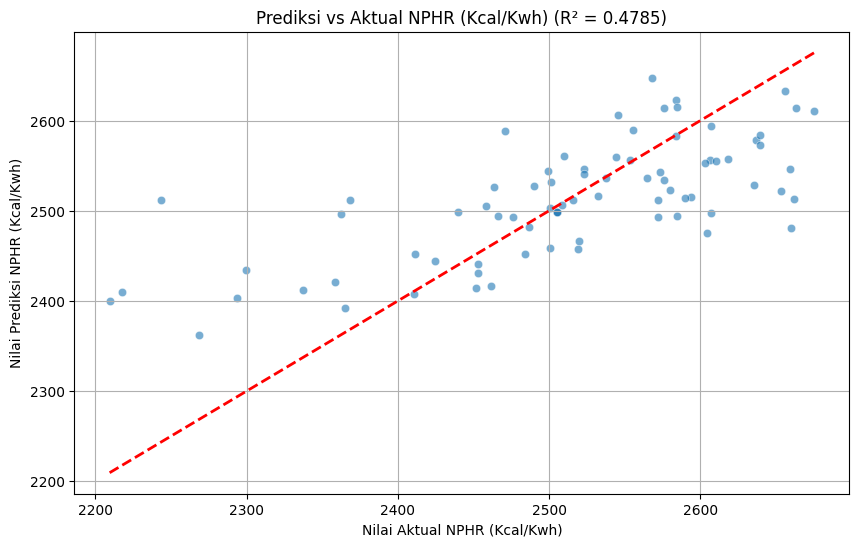

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. VISUALISASI HASIL PREDIKSI VS AKTUAL
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Nilai Aktual NPHR (Kcal/Kwh)')
plt.ylabel('Nilai Prediksi NPHR (Kcal/Kwh)')
plt.title(f'Prediksi vs Aktual NPHR (Kcal/Kwh) (R² = {r2:.4f})')
plt.grid(True)
plt.show()

In [10]:
import pandas as pd

# 7. TABEL PERBANDINGAN AKTUAL VS PREDIKSI
# Membuat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Absolute Error': np.abs(y_test - y_pred),
    'Percentage Error (%)': np.abs((y_test - y_pred) / y_test) * 100
})

# Menampilkan 10 baris pertama untuk pengecekan
print("Comparison Table (First 10 rows):")
print(comparison_df.head(10))

# Opsional: Simpan ke CSV jika diperlukan untuk laporan SEO
# comparison_df.to_csv('model_predictions_comparison.csv', index=False)

Comparison Table (First 10 rows):
     Actual Value  Predicted Value  Absolute Error  Percentage Error (%)
535   2500.496419      2459.042773       41.453647              1.657817
105   2470.561476      2588.109349      117.547873              4.757942
6     2656.199008      2633.114927       23.084080              0.869064
268   2543.905778      2559.590294       15.684516              0.616553
101   2635.265505      2528.558031      106.707474              4.049211
358   2583.902258      2623.297938       39.395680              1.524658
194   2217.502098      2409.660563      192.158465              8.665537
348   2505.527823      2498.079269        7.448555              0.297285
314   2532.434910      2516.534539       15.900371              0.627869
510   2411.266611      2452.061326       40.794714              1.691838


In [11]:
# 8. EXPORT TO EXCEL
# Menentukan nama file
file_name = "e. #2 model prediction comparison dataset 1 nphr.xlsx"

# Menyimpan DataFrame ke file Excel
comparison_df.to_excel(file_name, index=False)

print(f"Data successfully saved to {file_name}!")

Data successfully saved to e. #2 model prediction comparison dataset 1 nphr.xlsx!
